## Chapter 12

### Question 10: In this problem, we will generate simulated data, and then perform PCA and K-means clustering on the data.

#### a. Generate a simulated data set with 20 observations in each of three classes (i.e. 60 observations total), and 50 variables.

In [9]:
import numpy as np

np.random.seed(1)

# 20 observations per class, 50 variables, base random noise
class1 = np.random.normal(loc=0, scale=1, size=(20, 50))
class2 = np.random.normal(loc=0, scale=1, size=(20, 50))
class3 = np.random.normal(loc=0, scale=1, size=(20, 50))

# Shift the means so the three classes are actually distinct
class1 += 0     # baseline, no shift
class2 += 3     # shift every value up by 3
class3 -= 3     # shift every value down by 3

X = np.vstack([class1, class2, class3])
true_labels = np.array([0]*20 + [1]*20 + [2]*20)

print("Data shape:", X.shape)
print("Labels shape:", true_labels.shape)

Data shape: (60, 50)
Labels shape: (60,)


### (b) PCA: plot the first two principal component score vectors

In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_scores = pca.fit_transform(X)

print("PCA scores shape:", pca_scores.shape)

PCA scores shape: (60, 2)


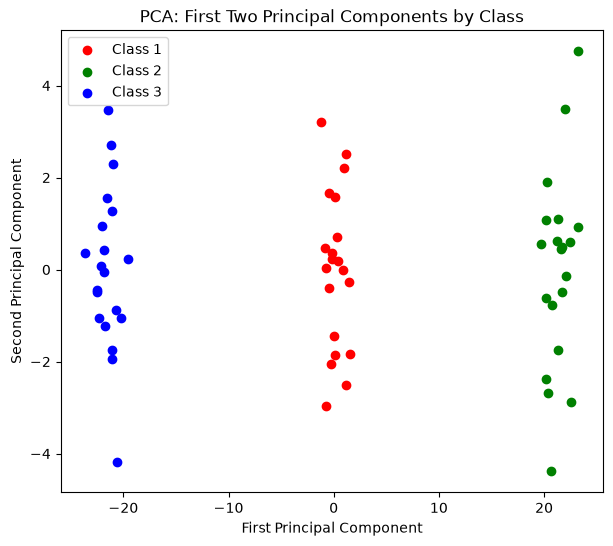

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))
colors = ['red', 'green', 'blue']
for i in range(3):
    plt.scatter(pca_scores[true_labels == i, 0],
                pca_scores[true_labels == i, 1],
                c=colors[i], label=f'Class {i+1}')

plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('PCA: First Two Principal Components by Class')
plt.legend()
plt.savefig('pca_plot.png', dpi=150)
plt.show()

### (c) K-means clustering with K = 3

In [17]:
from sklearn.cluster import KMeans

kmeans3 = KMeans(n_clusters=3, n_init=20, random_state=1)
cluster_labels3 = kmeans3.fit_predict(X)

print("Cluster assignments:", cluster_labels3)

Cluster assignments: [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [19]:
import pandas as pd

comparison = pd.crosstab(true_labels, cluster_labels3, rownames=['True Class'], colnames=['K-means Cluster'])
print(comparison)

K-means Cluster   0   1   2
True Class                 
0                 0   0  20
1                20   0   0
2                 0  20   0


### (d) K-means clustering with K = 2

In [22]:
kmeans2 = KMeans(n_clusters=2, n_init=20, random_state=1)
cluster_labels2 = kmeans2.fit_predict(X)

comparison2 = pd.crosstab(true_labels, cluster_labels2, rownames=['True Class'], colnames=['K-means Cluster'])
print(comparison2)

K-means Cluster   0   1
True Class             
0                20   0
1                20   0
2                 0  20


### (e) K-means clustering with K = 4

In [25]:
kmeans4 = KMeans(n_clusters=4, n_init=20, random_state=1)
cluster_labels4 = kmeans4.fit_predict(X)

comparison4 = pd.crosstab(true_labels, cluster_labels4, rownames=['True Class'], colnames=['K-means Cluster'])
print(comparison4)

K-means Cluster   0   1  2   3
True Class                    
0                20   0  0   0
1                 0   0  5  15
2                 0  20  0   0


### (f) K-means with K=3 on the PCA scores (not the raw data)

In [28]:
kmeans_pca = KMeans(n_clusters=3, n_init=20, random_state=1)
cluster_labels_pca = kmeans_pca.fit_predict(pca_scores)

comparison_pca = pd.crosstab(true_labels, cluster_labels_pca, rownames=['True Class'], colnames=['K-means Cluster'])
print(comparison_pca)

K-means Cluster   0   1   2
True Class                 
0                 0   0  20
1                20   0   0
2                 0  20   0


### (g) K-means with K=3 on scaled data (StandardScaler)

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans_scaled = KMeans(n_clusters=3, n_init=20, random_state=1)
cluster_labels_scaled = kmeans_scaled.fit_predict(X_scaled)

comparison_scaled = pd.crosstab(true_labels, cluster_labels_scaled, rownames=['True Class'], colnames=['K-means Cluster'])
print(comparison_scaled)

K-means Cluster   0   1   2
True Class                 
0                 0   0  20
1                20   0   0
2                 0  20   0
